In [31]:
from qdrant_client import QdrantClient
from qdrant_client.http.models import Filter, FieldCondition, MatchValue
from qdrant_client.models import Distance, VectorParams, PointStruct
from tqdm import tqdm

from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from scipy.sparse import csgraph
from sklearn.manifold import SpectralEmbedding
from sklearn.preprocessing import normalize

import numpy as np
import torch
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

from transformers import (AutoModel, AutoProcessor, AutoTokenizer, CLIPModel, CLIPConfig, CLIPTokenizerFast
                          , CLIPProcessor, SiglipProcessor, SiglipModel)

from utils.metrics import iterate_ds, mean_reciprocal_rank, recall_at_k
from spectral_code import compute_spectral_embedding
from initialise_vector_database import create_collections

# Step 1: Read in Short generated captions CSV with image paths installed locally

In [32]:
df_captions = pd.read_csv("./dataset.csv")

In [33]:
df_captions=df_captions[:15]
while True:
    choice1 = input("Choose: 'l' for long captions or 's' for short captions: ").strip().lower()
    if choice1 in ['l', 's']:
        break
    print("Invalid choice. Please enter 'l' or 's'.")

if choice1 == 'l':
    captions = "vlm_caption"
else:
    captions = "original_caption"

## Retrieve each image path using ids column

In [34]:
ids = df_captions["id"]

Now, we use these ids to search for images to get all relevant images for each path. The format of image paths is `img_{id}`

In [35]:
valid_img_paths = [f'./images/img_{id}.jpg' for id in ids]

# Step 2: Load in models and vector database, and convert image and text to embeddings

In [36]:
# Load in Qdrant client
client = QdrantClient(url="http://localhost:6333")

In [37]:
# Load in the model to be used

device = "cuda" if torch.cuda.is_available() else "cpu"

while True:
    choice2 = input("Choose: 'clip' for clip model, or 'longclip' for longclip model, or 'jinaclip' for jinaclip model: ").strip().lower()
    if choice2 in ['clip', 'longclip', 'jinaclip']:
        break
    print("Invalid choice. Please enter 'clip', 'jinalip' or 'longclip'.")

def load_model(model_name="clip"):
    if model_name == "clip":
        model_id = "openai/clip-vit-large-patch14" # changed model -> 428M 
        model = CLIPModel.from_pretrained(model_id).to(device)
        processor = CLIPProcessor.from_pretrained(model_id)
        dimension = 768
        max_tokens = 77
    elif model_name == "jinaclip":
        model_id = "jinaai/jina-clip-v1"
        model = AutoModel.from_pretrained(model_id, trust_remote_code=True).to(device)
        processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
        dimension = 768
        max_tokens = 77
        # add max_tokens
    elif model_name == "longclip":
        model_id = "zer0int/LongCLIP-GmP-ViT-L-14" # 428M
        config = CLIPConfig.from_pretrained(model_id)
        config.text_config.max_position_embeddings = 248
        model = CLIPModel.from_pretrained(model_id, config=config).to(device)
        processor = CLIPProcessor.from_pretrained(model_id, padding="max_length", max_length=248)
        max_tokens = 248
        dimension = 768
    else:
        raise ValueError(f"Unknown model name: {model_name}")
    
    return model, processor, dimension

model, processor, dimension = load_model(choice2)
create_collections(dimension)


In [38]:
embeddings = []
for path in valid_img_paths:
    try:
        image = Image.open(path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt")
        with torch.no_grad():
            features = model.get_image_features(**inputs)
        # features = features / features.norm(p=2, dim=-1, keepdim=True)
        embeddings.append(features.cpu().numpy().squeeze())
    except Exception as e:
        print(f"Error processing image {path}: {e}")

# Step 3: Load the embeddings into Qdrant

In [39]:
client = QdrantClient(host="localhost", port=6333)
points = [
    PointStruct(id=idx, vector=vec, payload={})
    for idx, vec in zip(ids, embeddings)
]

client.upsert(collection_name="image_db", points=points)

UpdateResult(operation_id=0, status=<UpdateStatus.COMPLETED: 'completed'>)

# Step 4: Recording Metrics

In [40]:
df_captions[:10]

,url,original_caption,vlm_caption,is_downloaded,id
0,https://thumbs.dreamstime.com/b/car-riding-wet...,Car riding on wet street. Car driving on wet c...,This image displays:\n\nA black car driving t...,True,1
1,https://images.pexels.com/photos/770224/pexels...,Water Coming Out Of A Pipe,This image displays: A large rusty pipe with ...,True,2
2,https://filmfare.wwmindia.com/content/2017/jul...,MARCH 2009 ''It's sad that a boy and girl can ...,This image displays: three pictures of Katrin...,True,3
3,https://southernersays.com/wp-content/uploads/...,Humpback Whale tail in the Bay of Banderas,This image displays:\nA photograph of a whale...,True,4
4,https://i.pinimg.com/originals/9a/f5/a6/9af5a6...,"The gaming Team logo of team DUO Team Logo, My...","This image displays:\n\nText that reads ""20% ...",True,5
5,https://themaydan.com/wp-content/uploads/2019/...,"Tea, chilies, and takeaway: what food choices ...",This image displays: A family of four is sitt...,True,6
6,https://i.pinimg.com/originals/ae/f4/f3/aef4f3...,The Bath Co. Camberley satin grey vanity unit ...,This image displays:\n\nA bathroom vanity wit...,True,7
7,https://photogallery.indiatimes.com/photo/6551...,Celebs attend the launch of a style store,This image displays: A young woman with long ...,True,8
8,https://images.squarespace-cdn.com/content/v1/...,Europe always amazes me on how well their arch...,"This image displays:\n\nAn oculus, which is a...",True,9
9,https://slideplayer.com/slide/13821916/85/imag...,The Development of the Court,This image displays:\n\nA photograph of the S...,True,10


In [41]:
avg_mrr = iterate_ds(10, df_captions, "mrr", processor, model, captions, client, "image_db", device)
print(avg_mrr)

Calculating mrr: 100%|██████████| 15/15 [00:02<00:00,  5.67it/s]

0.9111111111111111


In [42]:
avg_recall_at_1 = iterate_ds(1, df_captions, "recall@k", processor, model, captions, client, "image_db", device)

Calculating recall@k: 100%|██████████| 15/15 [00:01<00:00, 10.27it/s]


In [43]:
print(avg_recall_at_1)

0.8666666666666667


In [44]:
avg_recall_at_5 = iterate_ds(5, df_captions, "recall@k", processor, model, captions, client, "image_db", device)
print(avg_recall_at_5)

Calculating recall@k:   0%|          | 0/15 [00:00<?, ?it/s]

Calculating recall@k: 100%|██████████| 15/15 [00:01<00:00,  9.41it/s]

0.9333333333333333


In [45]:
avg_recall_at_10 = iterate_ds(10, df_captions, "recall@k", processor, model, captions, client, "image_db", device)
print(avg_recall_at_10)

Calculating recall@k:   0%|          | 0/15 [00:00<?, ?it/s]

Calculating recall@k: 100%|██████████| 15/15 [00:01<00:00,  9.44it/s]

1.0


# Step 5: Visualise Results

In [46]:
# to visualise results, we need to plot the distances between embeddings. We thus need to calculate textual embeddings

og_captions =[i for i in df_captions["original_caption"]]
inputs = processor(text=og_captions, return_tensors="pt", padding=True, truncation=True, max_length=64)

# convert into a dictionary to tell to pass intput to device
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    text_embeddings = model.get_text_features(**inputs)

In [47]:
len(text_embeddings)

15

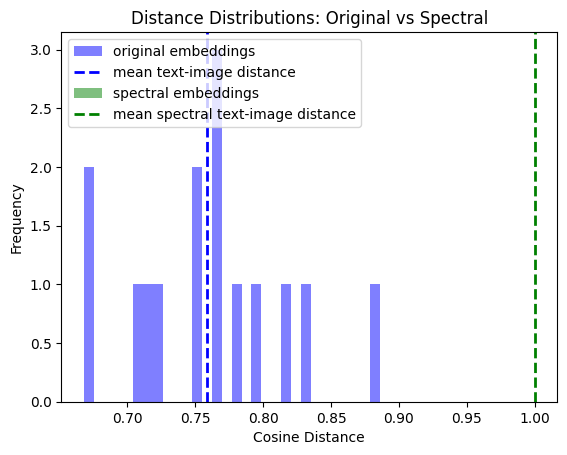

In [48]:
## NOTE: ADD SPECTRAL EMBEDDING DISTANCES
# retrieved from the following paper: https://arxiv.org/pdf/2505.03703
distance=cosine_distances
distances = distance(embeddings, text_embeddings)
gt_distances = np.diag(distances)
global_mean = np.mean(gt_distances)
plt.hist(gt_distances, bins=30, alpha=0.5, label="original embeddings", color='blue')
plt.axvline(global_mean, color='blue', linestyle='dashed', linewidth=2,
        label=f'mean text-image distance')

embeddings_norm = normalize(embeddings, axis=1)
text_embeddings_norm = normalize(text_embeddings, axis=1)

# spectral_output_dimension = 2 ** (math.floor(math.log2(dimension)))
n_nodes = len(embeddings_norm) + len(text_embeddings_norm)
spectral_output_dimension = min(64, n_nodes - 2)
# spectral_output_dimension = min(64, spectral_combined_output.shape[0] - 2)

spectral_combined_output = compute_spectral_embedding(
    image_embeddings=embeddings_norm,
    text_embeddings=text_embeddings_norm,
    n_components=spectral_output_dimension
)

spectral_image_embeddings = spectral_combined_output[:len(embeddings_norm)]
spectral_text_embeddings = spectral_combined_output[len(embeddings_norm):]

spectral_image_embeddings = normalize(spectral_image_embeddings, axis=1)
spectral_text_embeddings = normalize(spectral_text_embeddings, axis=1)

spectral_distances = cosine_distances(spectral_image_embeddings, spectral_text_embeddings)
spectral_gt_distances = np.diag(spectral_distances)
spectral_global_mean = np.mean(spectral_gt_distances)

plt.hist(spectral_gt_distances, bins=30, alpha=0.5, label="spectral embeddings", color='green')
plt.axvline(spectral_global_mean, color='green', linestyle='dashed', linewidth=2,
            label=f'mean spectral text-image distance')
plt.legend()
plt.title("Distance Distributions: Original vs Spectral")
plt.xlabel("Cosine Distance")
plt.ylabel("Frequency")
plt.show()

#A higher mean cosine distance in spectral embeddings isn’t necessarily a problem
# it’s often a sign the embedding is emphasizing global structure differently and 
# possibly reducing noise or modality gaps in a useful way.

In [49]:
client.delete_collection(collection_name="spectral_collection")

client.create_collection(collection_name="spectral_collection", vectors_config=VectorParams(size=(min(64, n_nodes - 2)), distance=Distance.COSINE))

points = []
for idx, vec in zip(ids, spectral_image_embeddings):
    if not isinstance(idx, (int, str)):
        raise ValueError(f"Invalid ID type: {idx} (must be int or str)")
    points.append(PointStruct(id=idx, vector=vec.astype(float).tolist(), payload={}))

client.upsert(
    collection_name="spectral_collection",
    points=points,
)

UpdateResult(operation_id=0, status=<UpdateStatus.COMPLETED: 'completed'>)

In [50]:
avg_mrr_spectral = iterate_ds(
    10, df_captions, "mrr", processor, model, captions,
    client, "spectral_collection", device,
    use_spectral=True,
    spectral_text_embeddings=spectral_text_embeddings
)
print(avg_mrr_spectral)

avg_recall_at_1_spectral = iterate_ds(
    1, df_captions, "recall@k", processor, model, captions,
    client, "spectral_collection", device,
    use_spectral=True,
    spectral_text_embeddings=spectral_text_embeddings
)


avg_recall_at_5_spectral = iterate_ds(
    5, df_captions, "recall@k", processor, model, captions,
    client, "spectral_collection", device,
    use_spectral=True,
    spectral_text_embeddings=spectral_text_embeddings
)
print(avg_recall_at_5_spectral)

avg_recall_at_10_spectral = iterate_ds(
    10, df_captions, "recall@k", processor, model, captions,
    client, "spectral_collection", device,
    use_spectral=True,
    spectral_text_embeddings=spectral_text_embeddings
)
print(avg_recall_at_10_spectral)


Calculating mrr: 100%|██████████| 15/15 [00:00<00:00, 54.05it/s]


0.45


Calculating recall@k: 100%|██████████| 15/15 [00:00<00:00, 74.07it/s]


0.5333333333333333


Calculating recall@k: 100%|██████████| 15/15 [00:00<00:00, 61.93it/s]

0.5333333333333333


In [51]:
print(avg_recall_at_1_spectral)
print(avg_recall_at_10_spectral)
print(avg_recall_at_5_spectral)

0.4
0.5333333333333333
0.5333333333333333


In [52]:
def visualize_embeddings_pca(image_embeddings: np.ndarray, text_embeddings: np.ndarray, dimensions=2):
    """
    Visualizes the distance between image and text embeddings using PCA.

    Args:
        image_embeddings - numpy array: Array of shape (N, D) for image features
        text_embeddings - numpy array: Array of shape (N, D) for text features
        dimensions - int: Number of dimensions for the graph. Can be either 2 or 3
    Returns:
        None
    """

    # stack all the embeddings so we can perform PCA
    combined = np.vstack([image_embeddings, text_embeddings])
    # perform PCA
    pca = PCA(n_components=dimensions)
    reduced = pca.fit_transform(combined)

    # differentiate between image and text embeddings 
    n = image_embeddings.shape[0]
    img_points = reduced[:n]
    txt_points = reduced[n:]

    # draw a 2d graph if dimensions are 2 and if not, we draw a 3D graph
    if dimensions == 2:
        # create a scatter plot
        plt.figure(figsize=(10, 8))
        plt.scatter(img_points[:, 0], img_points[:, 1], c='blue', label='Images', alpha=0.6)
        plt.scatter(txt_points[:, 0], txt_points[:, 1], c='red', label='Captions', alpha=0.6)

        # draw lines to visualise between each embedding
        for i in range(n):
            plt.plot([img_points[i, 0], txt_points[i, 0]],
                    [img_points[i, 1], txt_points[i, 1]],
                    c='gray', linestyle='--', linewidth=0.5)
            plt.xlabel("PCA 1")
            plt.ylabel("PCA 2")
    elif dimensions == 3:
        fig = plt.figure(figsize=(12, 9))
        ax = fig.add_subplot(111, projection='3d')

        # Scatter plot
        ax.scatter(img_points[:, 0], img_points[:, 1], img_points[:, 2], c='blue', label='Images', alpha=0.7)
        ax.scatter(txt_points[:, 0], txt_points[:, 1], txt_points[:, 2], c='red', label='Captions', alpha=0.7)

        # Draw lines between matching pairs
        for i in range(n):
            ax.plot(
                [img_points[i, 0], txt_points[i, 0]],
                [img_points[i, 1], txt_points[i, 1]],
                [img_points[i, 2], txt_points[i, 2]],
                c='gray', linestyle='--', linewidth=0.5
            )
        ax.set_ylabel("PCA 2")
        ax.set_xlabel("PCA 1")
        ax.set_zlabel("PCA 3")
        

    plt.title("PCA Visualization of Image and Text Embeddings")
    plt.legend()
    plt.grid(True)
    plt.show()

In [53]:
from mpl_toolkits.mplot3d import Axes3D
import umap.umap_ as umap
def visualize_embeddings_umap(image_embeddings: np.ndarray, text_embeddings: np.ndarray, semantic_classes: np.ndarray, dimensions=2):
    """
    Visualizes the distance between image and text embeddings using UMAP.

    Args:
        image_embeddings - numpy array: Array of shape (N, D) for image features.
        text_embeddings - numpy array: Array of shape (N, D) for text features.
        semantic_classes - numpy array: Array of shape (N,) containing class labels for coloring.
        dimensions - int: Number of dimensions for the graph. Can be either 2 or 3.
    Returns:
        None
    """

    combined = np.vstack([image_embeddings, text_embeddings])
    
    # Perform UMAP
    reducer = umap.UMAP(n_components=dimensions, n_neighbors=10, min_dist=0.1, metric='cosine')
    reduced = reducer.fit_transform(combined)

    n = image_embeddings.shape[0]
    img_points = reduced[:n]
    txt_points = reduced[n:]
    
    # Use different markers for images and text for cross-modal visualization
    image_markers = 'o'
    text_markers = '^'

    if dimensions == 2:
        plt.figure(figsize=(10, 8))
        
        scatter_img = plt.scatter(img_points[:, 0], img_points[:, 1], c=semantic_classes, cmap='viridis', marker=image_markers, s=50, label='Images')
        scatter_txt = plt.scatter(txt_points[:, 0], txt_points[:, 1], c=semantic_classes, cmap='viridis', marker=text_markers, s=50, label='Captions')

        for i in range(n):
            plt.plot([img_points[i, 0], txt_points[i, 0]],
                     [img_points[i, 1], txt_points[i, 1]],
                     c='gray', linestyle='--', linewidth=0.5)

        plt.xlabel("UMAP 1")
        plt.ylabel("UMAP 2")
        

    elif dimensions == 3:
        fig = plt.figure(figsize=(12, 9))
        ax = fig.add_subplot(111, projection='3d')

        ax.scatter(img_points[:, 0], img_points[:, 1], img_points[:, 2], c=semantic_classes, cmap='viridis', marker=image_markers, s=50, label='Images', alpha=0.7)
        ax.scatter(txt_points[:, 0], txt_points[:, 1], txt_points[:, 2], c=semantic_classes, cmap='viridis', marker=text_markers, s=50, label='Captions', alpha=0.7)

        for i in range(n):
            ax.plot(
                [img_points[i, 0], txt_points[i, 0]],
                [img_points[i, 1], txt_points[i, 1]],
                [img_points[i, 2], txt_points[i, 2]],
                c='gray', linestyle='--', linewidth=0.5
            )
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.set_zlabel("UMAP 3")
        

    plt.title(f"UMAP Visualization of Image and Text Embeddings ({dimensions}D)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return img_points, txt_points

In [54]:
# convert outer list which stores numpy arrays into a numpy array
img_embeddings_np = np.stack(embeddings)
text_embeddings_np = np.stack(text_embeddings)

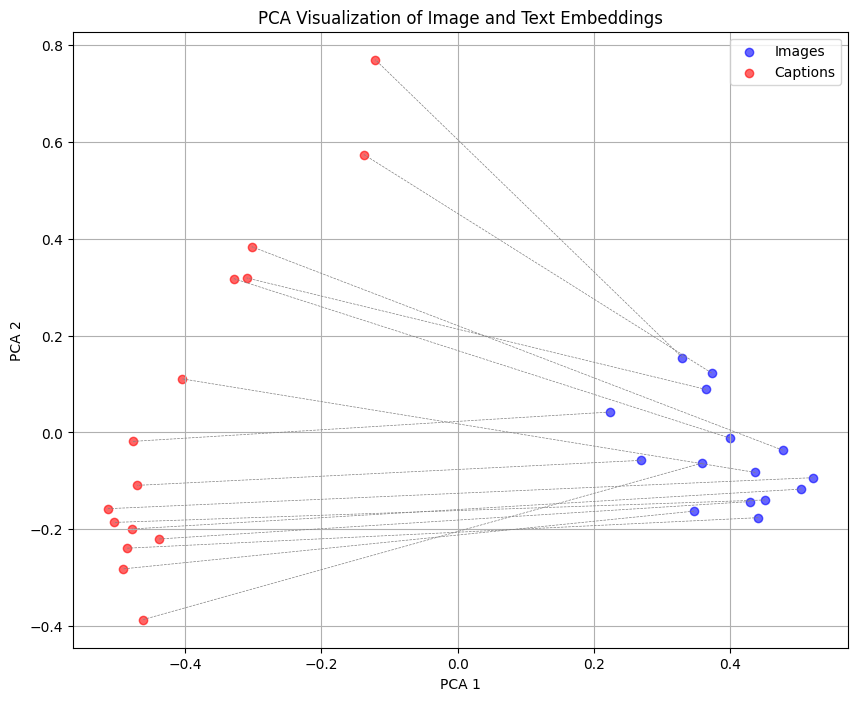

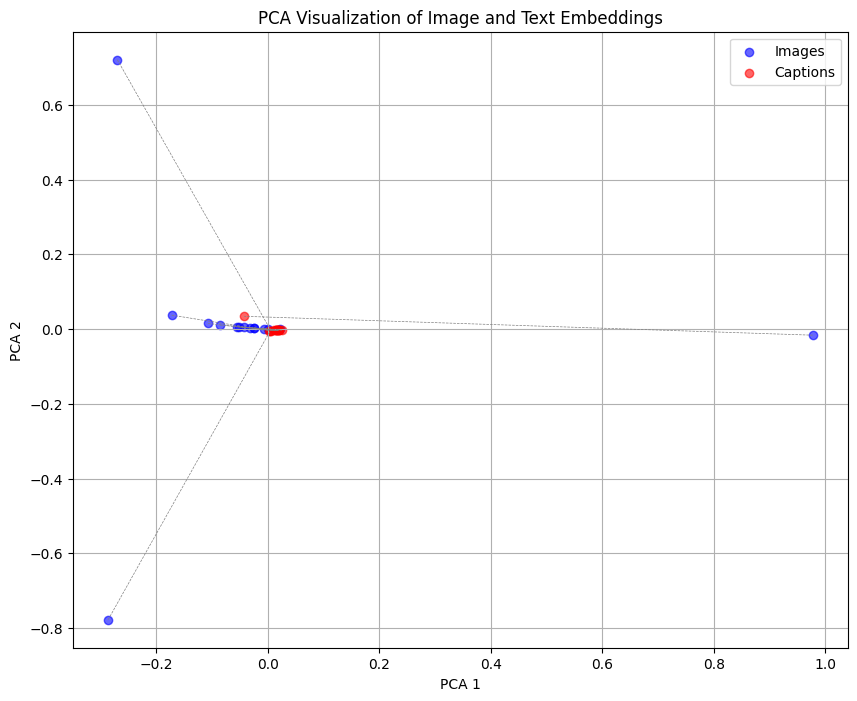

In [55]:
visualize_embeddings_pca(embeddings_norm, text_embeddings_norm, 2)
visualize_embeddings_pca(spectral_image_embeddings, spectral_text_embeddings, 2)

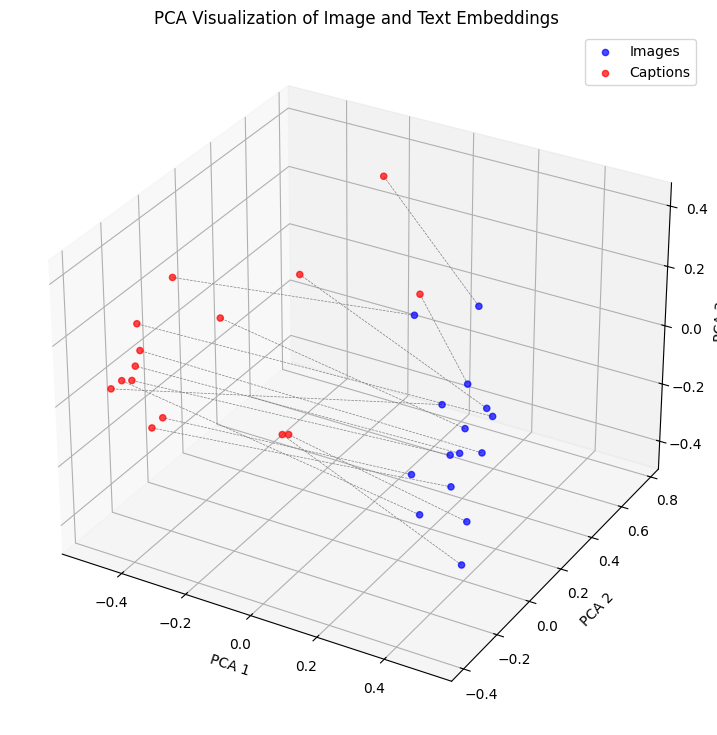

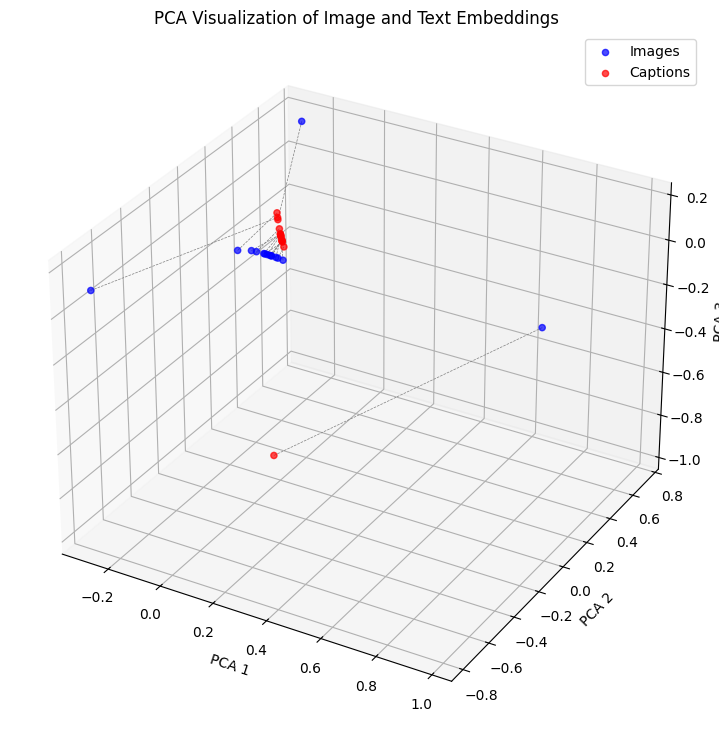

In [56]:
visualize_embeddings_pca(embeddings_norm, text_embeddings_norm, 3)
visualize_embeddings_pca(spectral_image_embeddings, spectral_text_embeddings, 3)

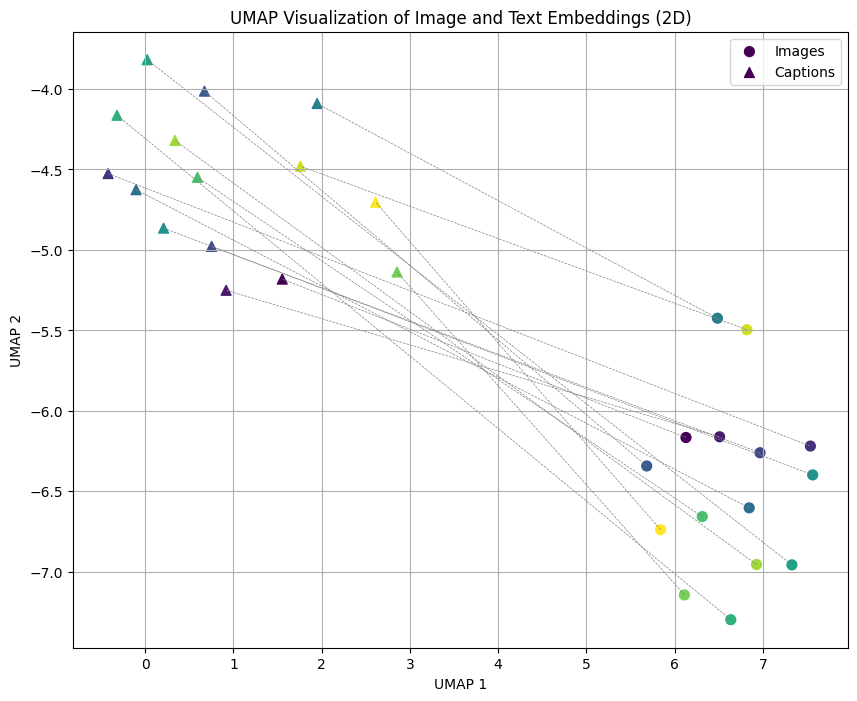

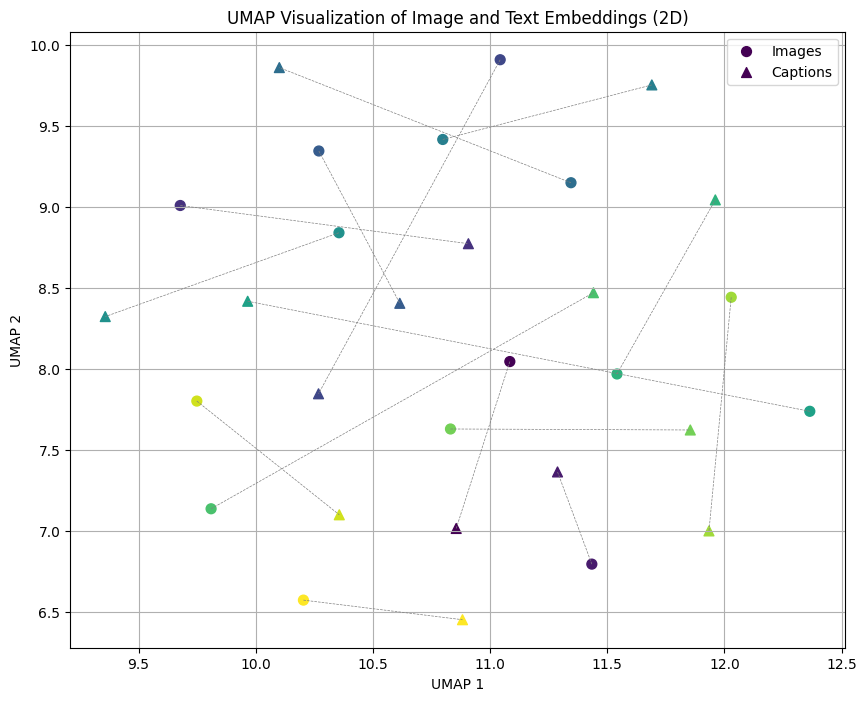

(array([[11.084037 ,  8.046228 ],
        [11.433952 ,  6.796195 ],
        [ 9.677722 ,  9.009271 ],
        [11.042877 ,  9.908819 ],
        [10.269128 ,  9.345591 ],
        [11.344988 ,  9.1497965],
        [10.797814 ,  9.4166765],
        [10.355008 ,  8.84107  ],
        [12.364007 ,  7.739266 ],
        [11.541332 ,  7.969577 ],
        [ 9.809293 ,  7.137793 ],
        [10.830844 ,  7.630096 ],
        [12.028682 ,  8.44295  ],
        [ 9.748414 ,  7.802366 ],
        [10.203294 ,  6.5741053]], dtype=float32),
 array([[10.855246 ,  7.016276 ],
        [11.287513 ,  7.3652196],
        [10.907246 ,  8.773589 ],
        [10.267703 ,  7.847431 ],
        [10.614486 ,  8.405717 ],
        [10.100504 ,  9.860295 ],
        [11.689939 ,  9.753423 ],
        [ 9.357714 ,  8.323776 ],
        [ 9.965407 ,  8.418424 ],
        [11.960853 ,  9.044011 ],
        [11.440808 ,  8.471186 ],
        [11.854073 ,  7.62404  ],
        [11.933749 ,  7.0011835],
        [10.356338 ,  7.1006474

In [57]:
visualize_embeddings_umap(img_embeddings_np, text_embeddings_np, ids, dimensions=2)
visualize_embeddings_umap(spectral_image_embeddings, spectral_text_embeddings, ids, dimensions=2)

Generating heatmaps...


C:\Users\payal\AppData\Local\Temp\ipykernel_41884\2162080585.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  text_embeddings_norm = text_embeddings / np.linalg.norm(text_embeddings, axis=1, keepdims=True)


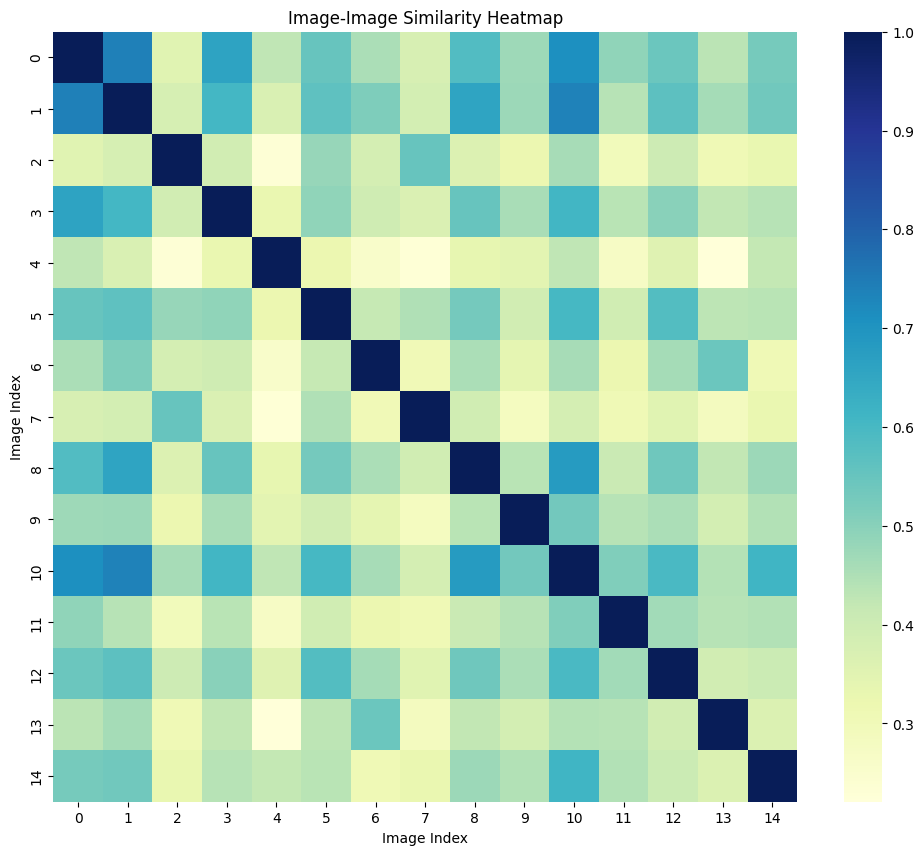

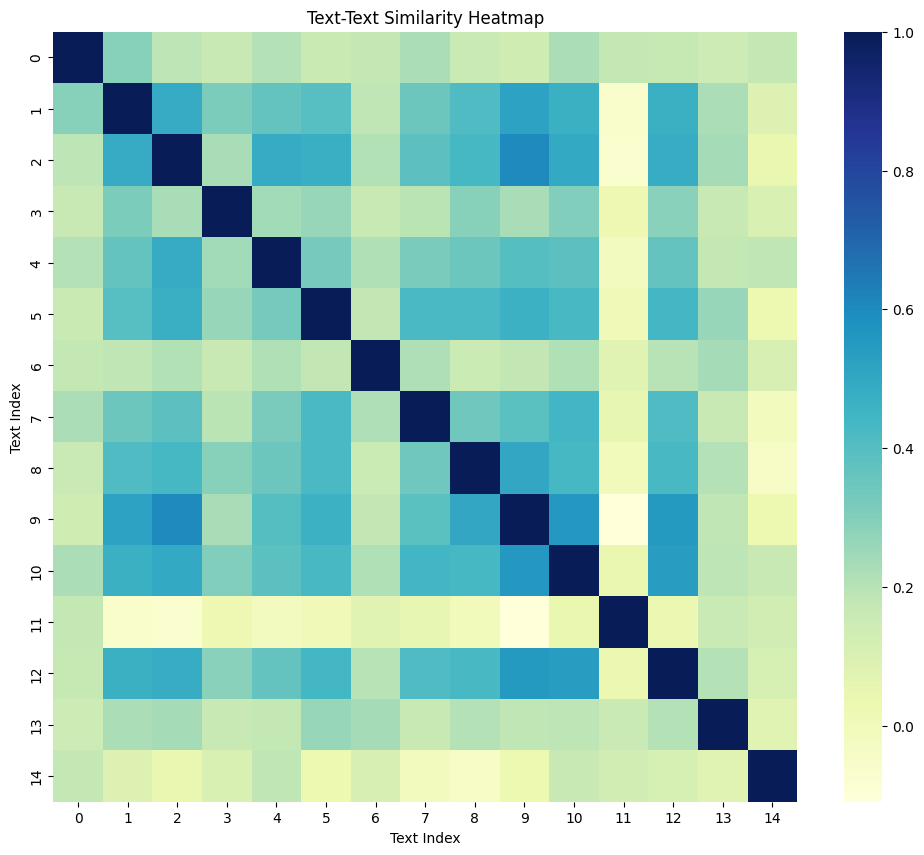

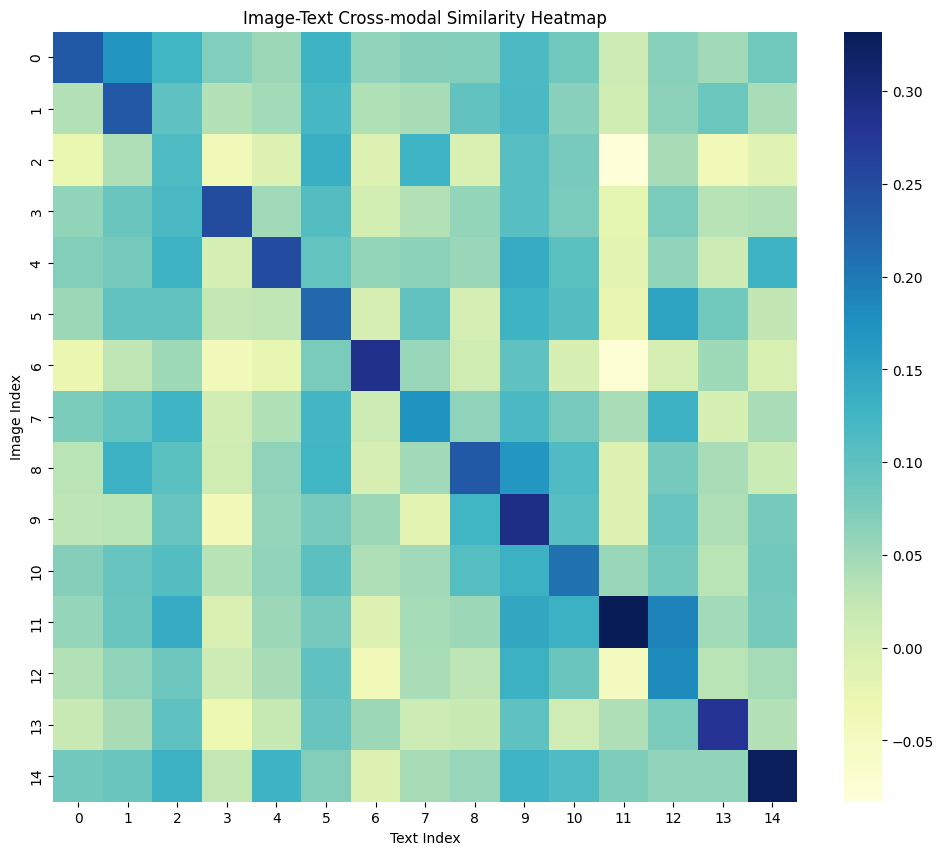

Calculating and visualizing metrics...
nDCG score: 0.9667
MAP score: 0.9459


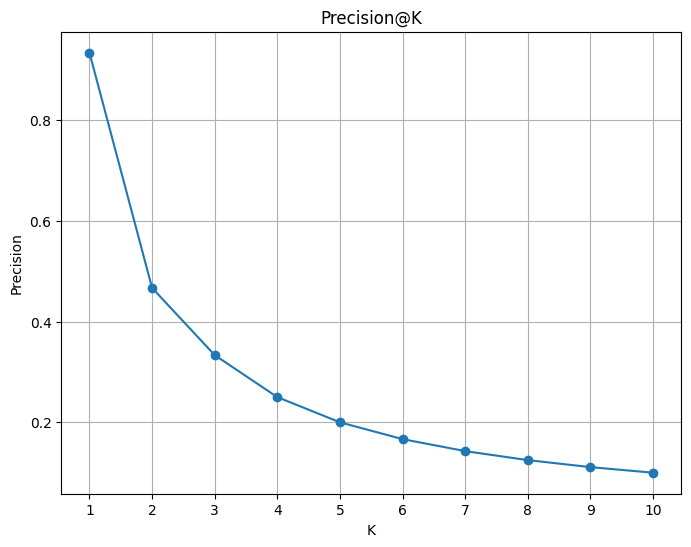

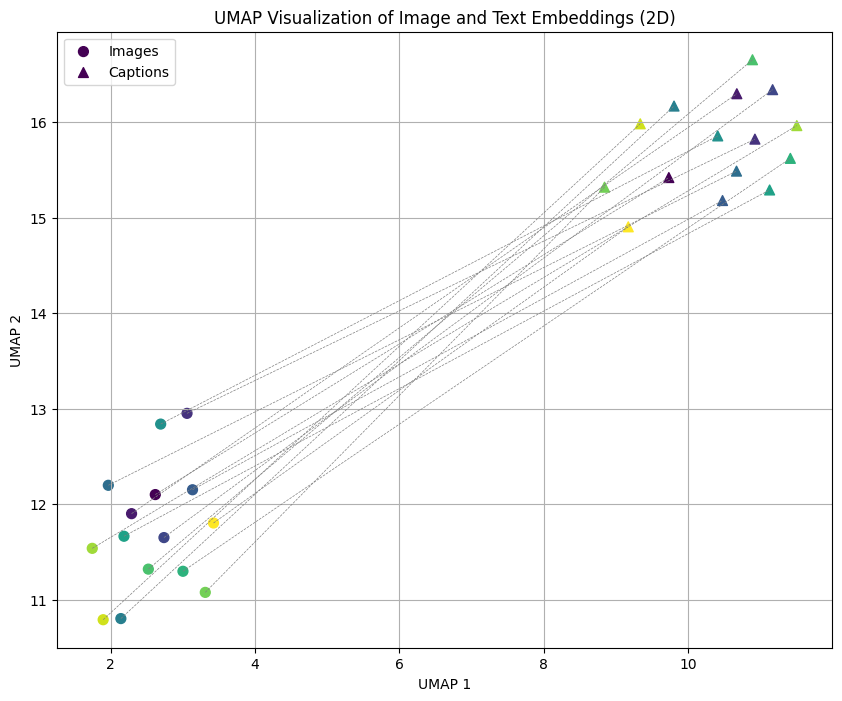

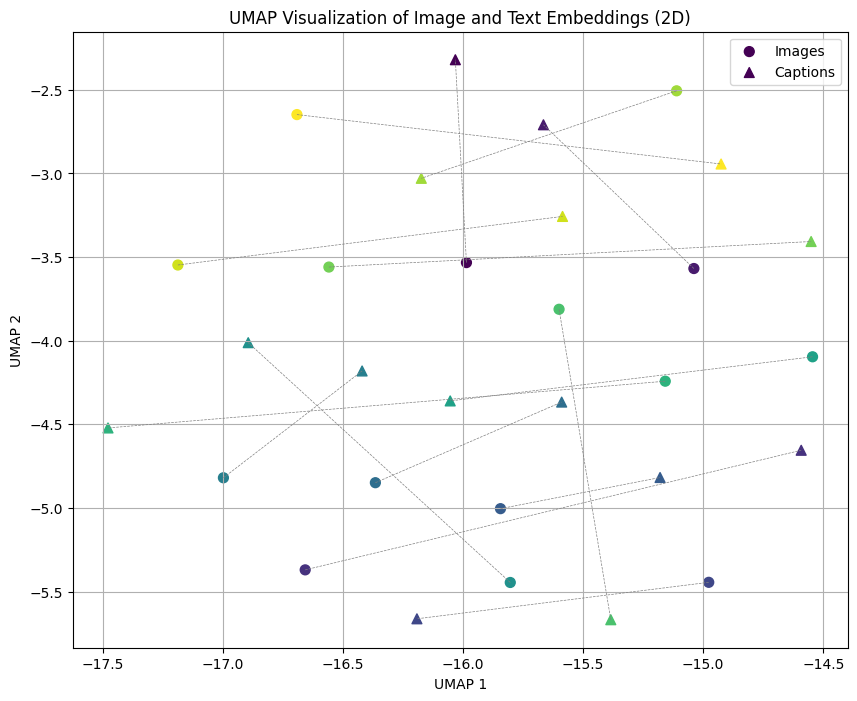

Locality-Preservation Score (UMAP): 1.0000 1.0000


In [58]:
import seaborn as sns
from sklearn.metrics import average_precision_score, ndcg_score

from utils.metrics import calculate_locality_preservation, calculate_precision_at_k
print("Generating heatmaps...")

# Normalize embeddings for cosine similarity
image_embeddings_norm = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
text_embeddings_norm = text_embeddings / np.linalg.norm(text_embeddings, axis=1, keepdims=True)

# 1. Image-Image Heatmap
image_image_similarity = cosine_similarity(image_embeddings_norm, image_embeddings_norm)
plt.figure(figsize=(12, 10))
sns.heatmap(image_image_similarity, cmap='YlGnBu')
plt.title('Image-Image Similarity Heatmap')
plt.xlabel('Image Index')
plt.ylabel('Image Index')
plt.show()

# 2. Text-Text Heatmap
text_text_similarity = cosine_similarity(text_embeddings_norm, text_embeddings_norm)
plt.figure(figsize=(12, 10))
sns.heatmap(text_text_similarity, cmap='YlGnBu')
plt.title('Text-Text Similarity Heatmap')
plt.xlabel('Text Index')
plt.ylabel('Text Index')
plt.show()

# 3. Image-Text Cross-modal Heatmap
image_text_similarity = cosine_similarity(image_embeddings_norm, text_embeddings_norm)
plt.figure(figsize=(12, 10))
sns.heatmap(image_text_similarity, cmap='YlGnBu')
plt.title('Image-Text Cross-modal Similarity Heatmap')
plt.xlabel('Text Index')
plt.ylabel('Image Index')
plt.show()


# --- Metric Calculations and Visualizations ---

print("Calculating and visualizing metrics...")
# Assuming a ground truth where each image is only related to its own caption
ground_truth = np.identity(len(embeddings))

# Calculate and print nDCG and MAP
ndcg_score_value = ndcg_score(ground_truth, image_text_similarity)
map_score_value = average_precision_score(ground_truth.ravel(), image_text_similarity.ravel())
print(f"nDCG score: {ndcg_score_value:.4f}")
print(f"MAP score: {map_score_value:.4f}")

# Visualize precision@K
k_values = range(1, 11)
precision_at_k_scores = [calculate_precision_at_k(image_text_similarity, ground_truth, k) for k in k_values]

plt.figure(figsize=(8, 6))
plt.plot(k_values, precision_at_k_scores, marker='o')
plt.title('Precision@K')
plt.xlabel('K')
plt.ylabel('Precision')
plt.xticks(k_values)
plt.grid(True)
plt.show()

img_points, txt_points = visualize_embeddings_umap(img_embeddings_np, text_embeddings_np, ids, dimensions=2)
img_points_after, txt_points_after = visualize_embeddings_umap(spectral_image_embeddings, spectral_text_embeddings, ids, dimensions=2)

# Now, use the returned img_points for the locality preservation metric
locality_preservation = calculate_locality_preservation(img_embeddings_np, img_points)
locality_preservation_after = calculate_locality_preservation(spectral_image_embeddings, img_points_after)
print(f"Locality-Preservation Score (UMAP): {locality_preservation:.4f} {locality_preservation_after:.4f}")